<a href="https://colab.research.google.com/github/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/blob/main/check_pde_residuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Calculates PDE residual MATLAB synthetic data to verify source accuracy.**

Load and Format Data

In [9]:
import os
import scipy.io
import numpy as np
import pandas as pd
import urllib.request

def get_data():
    file_path = '1D_Heat_Synthetic_Data.mat'

    if not os.path.isfile(file_path):
        print("Did not find", file_path)
        url = "https://github.com/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/raw/refs/heads/main/1D_Heat_Synthetic_Data.mat"
        urllib.request.urlretrieve(url, file_path)
        print("Downloaded file.")
    else:
        print("File already exists...")

    mat_data = scipy.io.loadmat(file_path)
    x = mat_data['x'].flatten()
    t = mat_data['t'].flatten()
    T = mat_data['T']

    X, Time = np.meshgrid(x, t, indexing='ij')
    df = pd.DataFrame({
        'x': X.flatten(), # Spatial grid array
        't': Time.flatten(), # Time grid array
        'T': T.flatten() # Target variable matrix, shape (len(x), len(t))
    })

    return x, t, T



Compute Numerical Derivatives

Use NumPy's central difference gradient function to calculate the first derivative with respect to time ($\frac{\partial T}{\partial t}$) and the second derivative with respect to space ($\frac{\partial^2 T}{\partial x^2}$).

In [11]:
x,t,T = get_data()

File already exists...


In [16]:
x,t,T = get_data()

# Calculate grid spacing
dx = x[1] - x[0]
dt = t[1] - t[0]

# Calculate dT/dt along the time axis (axis=1)
dT_dt = np.gradient(T, dt, axis=1)

# Calculate dT/dx, then differentiate again for d^2T/dx^2 along the spatial axis (axis=0)
dT_dx = np.gradient(T, dx, axis=0)
d2T_dx2 = np.gradient(dT_dx, dx, axis=0)

File already exists...


Calculate the PDE Residual

Plug the computed derivatives into your specific PDE formulation. For a standard 1D heat equation ($\frac{\partial T}{\partial t} - \alpha \frac{\partial^2 T}{\partial x^2} = 0$), the residual matrix is calculated as follows:

In [17]:
alpha = 0.01  # Replace with the exact thermal diffusivity used in the PINN

# The residual should ideally be 0 at every point
residual = dT_dt - alpha * d2T_dx2

mean_residual = np.mean(np.abs(residual))
max_residual = np.max(np.abs(residual))

print(f"Mean MATLAB PDE Residual: {mean_residual:.4e}")
print(f"Max MATLAB PDE Residual: {max_residual:.4e}")

Mean MATLAB PDE Residual: 1.9465e-03
Max MATLAB PDE Residual: 1.1742e-01


# What do the residuals mean?

These results confirm that the MATLAB dataset itself violates the continuous PDE.

A mean residual means the synthetic data deviates from the actual differential equation.

**Why the PINN is performing correctly:**

The PINN is strictly adhering to the physics: DeepXDE evaluates the exact continuous PDE using Automatic Differentiation rather than discrete grid approximations.

Because it learns a smooth, continuous representation of the domain, it bypasses the numerical artifacts created by MATLAB's solver.

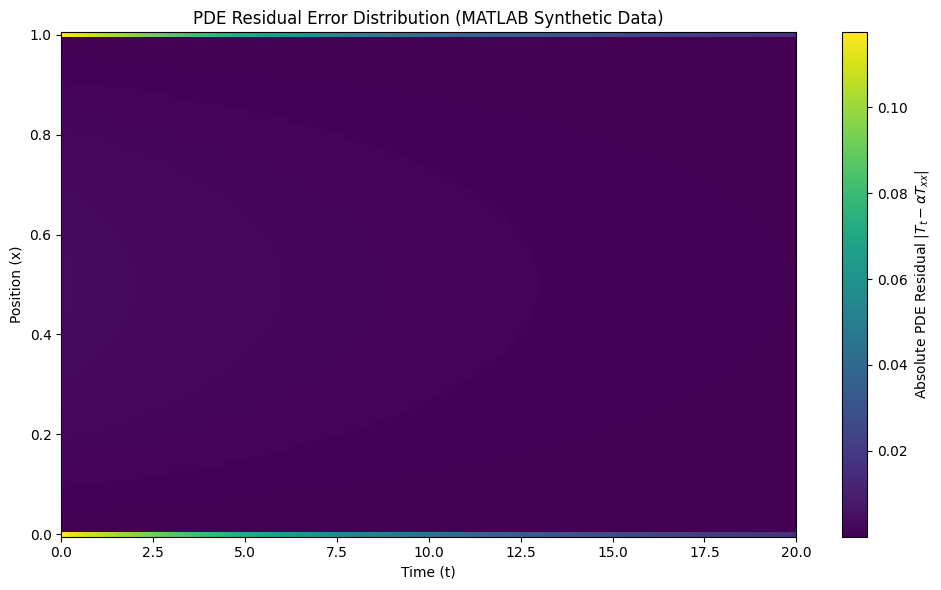

In [20]:
import matplotlib.pyplot as plt

# Meshgrid matching indexing='ij' format (len(x), len(t))
X, Time = np.meshgrid(x, t, indexing='ij')

plt.figure(figsize=(10, 6))
# Plot absolute residual heatmap across space (x) and time (t)
pcm = plt.pcolormesh(Time, X, np.abs(residual), cmap='viridis', shading='auto')

cbar = plt.colorbar(pcm)
cbar.set_label('Absolute PDE Residual $|T_t - \\alpha T_{xx}|$')

plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.title('PDE Residual Error Distribution (MATLAB Synthetic Data)')
plt.tight_layout()
plt.show()

Error Artifacts Are Strictly Concentrated at the Boundaries ($x = 0$ and $x = 1.0$)The bright yellow/green horizontal stripes along the extreme top ($x = 1.0$) and bottom ($x = 0.0$) boundaries account for the high maximum residual